In [1]:
import os
import rasterio
import geopandas as gpd 
import matplotlib.pyplot as plt
import rioxarray as rxr
from rasterio.mask import mask
import matplotlib.ticker as ticker
import glob
from datetime import datetime
import pandas as pd
from metloom.pointdata import SnotelPointData
import numpy as np
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [9]:
dir = "C:/Users/RDCRLSMC/Desktop/IDAHO_ALS/2026"

raster_dict = {}
for root, dirs, files in os.walk(dir):
    for filename in files:
        if "50m_clip" in filename:
            full_path = os.path.join(root, filename)
            result = filename.split("_")
            name = result[0]
            raster_dict[name] = os.path.abspath(full_path)

print(raster_dict)

{'20251203': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251203_MCS_50m_clip.tif', '20251213': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251213_MCS_50m_clip.tif', '20251220': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20251220_MCS_50m_clip.tif', '20260110': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260110_MCS_50m_clip.tif', '20260126': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260126_MCS_50m_clip.tif', '20260131': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260131_MCS_50m_clip.tif', '20260207': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260207_MCS_50m_clip.tif', '20260222': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260222_MCS_50m_clip.tif', '20260226': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260226_MCS_50m_clip.tif', '20260303': 'C:\\Users\\RDCRLSMC\\Desktop\\IDAHO_ALS\\2026\\20260303_MCS_50m_clip.tif'}


In [3]:
for i, (date, raster) in enumerate(raster_dict.items()):
    print(os.path.join(dir, raster))
    print(type(raster))
    with rasterio.open(os.path.join(dir, raster)) as src:
        print(src.crs)

C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251203_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251213_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251220_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260110_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260126_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260131_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260207_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260222_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260226_MCS-snowdepth_master_100m.tif
<class 'str'>
EPSG:32611
C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260303_MCS-s

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_3612\19241824.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


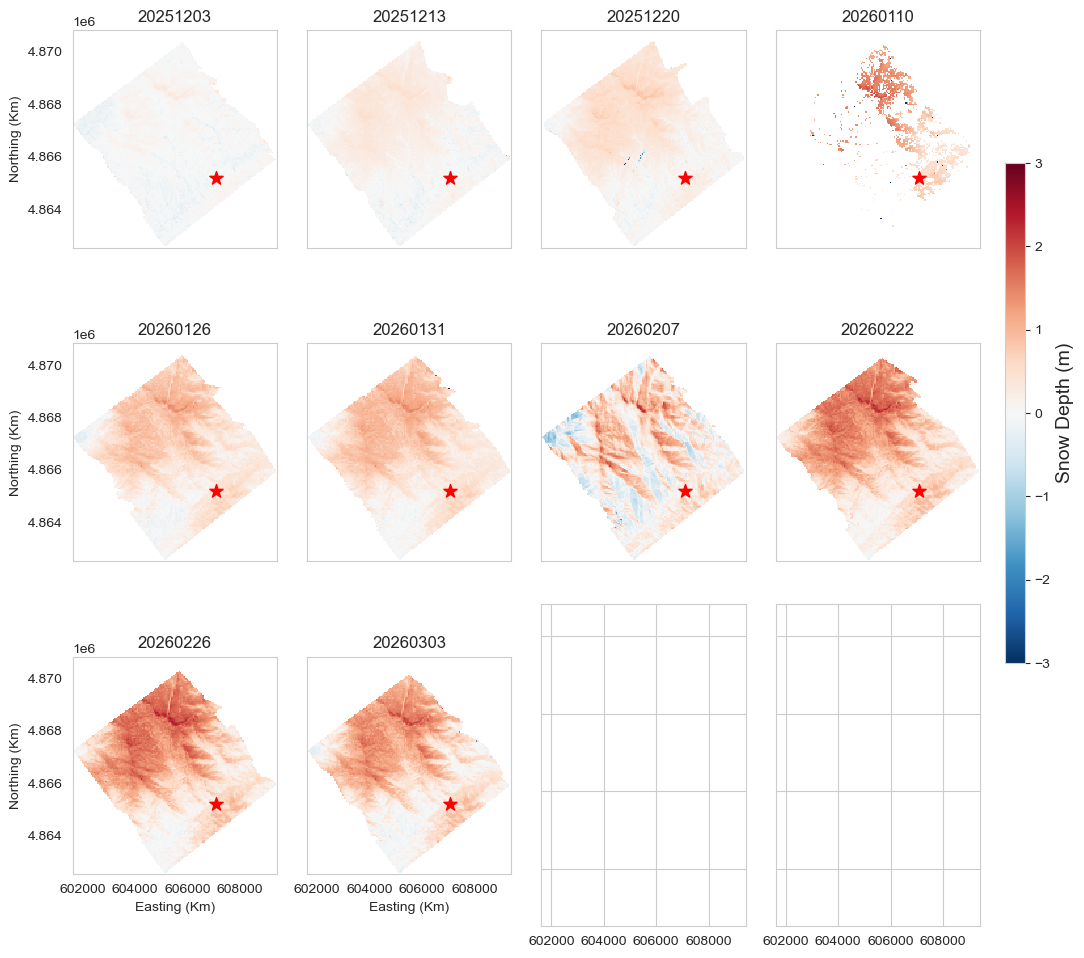

In [11]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

vcenter = 0
vmin = -3
vmax = 3
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10,10), sharex=True, sharey=True)
for i, (date, raster) in enumerate(raster_dict.items()):
    if i < len(raster_dict.items()):
        ax = axes.flatten()[i]
        snow_depth = rxr.open_rasterio(raster, masked=True)
        snow_depth = snow_depth.where(snow_depth > -5)
        im = snow_depth.plot(ax=ax, cmap=colormap, vmin=vmin, vmax=vmax, add_colorbar=False, robust=True)
        # gdf_20220217.plot(ax=ax, color='none', edgecolor='red')
        ax.scatter(607084.3493239387, 4865185.334007569, marker='*', s=100, color="red", label='SNOTEL')
        ax.set_title(date)
        ax.set_aspect('equal')
        ax.set_xlabel('Easting (Km)')
        ax.set_ylabel('Northing (Km)')
        ax.label_outer()  # Hides the labels of the shared axes

cbar_ax = fig.add_axes([1.01, 0.3, 0.02, 0.5])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth (m)', fontsize=14)

plt.tight_layout()
plt.show()

In [87]:
from metloom.pointdata import SnotelPointData


snotel_point = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID

# get the daily data for the snotel site for the specified date range and variables
WY26 = snotel_point.get_daily_data(
    datetime(2025, 10, 1), datetime(2026, 1, 30),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [84]:
# Let's look at our old friend banner summit
from metloom.pointdata import SnotelPointData

pt = SnotelPointData("637:ID:SNTL", "MCS")

# start data and end date
start_date = datetime(2025, 10, 1)
end_date = datetime(2023, 3, 1)
# Notice this is a list
variables = [pt.ALLOWED_VARIABLES.SNOWDEPTH]

# request the data
df_snotel = pt.get_daily_data(start_date, end_date, variables)
df_snotel.head(10)


No SNOWDEPTH found for MCS


AttributeError: 'NoneType' object has no attribute 'head'

In [ ]:
df = pd.DataFrame(raster_dict.items(), columns=['Filename', 'Filepath'])

In [67]:
df['Date'] = pd.to_datetime(df['Filename'], format='%Y%m%d')
df

,Filename,Filepath,Date
0,20251203,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251...,2025-12-03
1,20251213,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251...,2025-12-13
2,20251220,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251...,2025-12-20
3,20260110,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-01-10
4,20260126,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-01-26
5,20260131,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-01-31
6,20260207,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-02-07
7,20260222,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-02-22
8,20260226,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-02-26
9,20260303,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-03-03


In [77]:
lidar_mean = []
lidar_std = []

for filename, raster in raster_dict.items():
        sd = rxr.open_rasterio(raster, masked = True)   
        date = pd.to_datetime(filename, format='%Y%m%d')
        #plot the LiDAR mean and std
        date_yy = date.year
        date_mm = date.month
        #if the mm greater than 9 then it is next year
        if date_mm > 9:
            date_yy = date_yy + 1
        date_mm_dd = date.strftime('%m-%d')     
        lidar_mean.append(round(sd.mean().item(), 2))
        lidar_std.append(round(sd.std().item(), 2))

    #add the lidar mean and std to the snotel dataframe
df['LiDAR Mean (m)'] = lidar_mean
df['LiDAR Std (m)'] = lidar_std

    #find the difference between the snotel and lidar
#df['Mean Difference (m)'] = df['Snow Depth (m)'] - df['LiDAR Mean (m)']
    
    
print(df)

   Filename                                           Filepath       Date  \
0  20251203  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251... 2025-12-03   
1  20251213  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251... 2025-12-13   
2  20251220  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251... 2025-12-20   
3  20260110  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-01-10   
4  20260126  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-01-26   
5  20260131  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-01-31   
6  20260207  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-02-07   
7  20260222  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-02-22   
8  20260226  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-02-26   
9  20260303  C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260... 2026-03-03   

   LiDAR Mean (m)  LiDAR Std (m)  
0           -0.04           0.34  
1            0.03           0.32  
2            0.11           0.43  
3           

In [78]:
df

,Filename,Filepath,Date,LiDAR Mean (m),LiDAR Std (m)
0,20251203,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251...,2025-12-03,-0.04,0.34
1,20251213,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251...,2025-12-13,0.03,0.32
2,20251220,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20251...,2025-12-20,0.11,0.43
3,20260110,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-01-10,0.42,0.60
4,20260126,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-01-26,0.21,0.47
5,20260131,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-01-31,0.25,0.49
6,20260207,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-02-07,0.52,0.74
7,20260222,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-02-22,0.45,0.67
8,20260226,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-02-26,0.41,0.69
9,20260303,C:\Users\RDCRLSMC\Desktop\IDAHO_ALS\2026\20260...,2026-03-03,0.34,0.62


In [69]:
def snotel_lidar_compare(stationID, sd_list = [], start_year = 2020, end_year = 2024):
    import matplotlib.dates as mdates
    snotel_point = SnotelPointData(stationID, "MyStation")
    data = snotel_point.get_daily_data(datetime(start_year -1, 10, 1), datetime(end_year, 9, 30),
                                    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
    data['SNOWDEPTH (m)'] = data['SNOWDEPTH'] * 0.0254 #convert to meters
    data['Date (MM-DD)'] = data.index.strftime('%m-%d') #add a new column (Date (MM-DD)) to the dataframe
    data.index = data.index.strftime('%Y-%m-%d') #convert the datetime index to YYYY-MM-DD

    #merge the snotel data with the dates dataframe
    snotel_vals = df.merge(data, left_index=True, right_index=True, how='left')
    snotel_vals.index = pd.to_datetime(snotel_vals.index)

    # # Create a figure
    fig, ax = plt.subplots(figsize=(15, 8))
    #create a dictionary to map the year to a color
    colors = {2020: 'blue', 2021: 'orange', 2022: 'green', 2023: 'red', 2024: 'purple'}
    #plot the data for each year in a different color : Use water year so year starts from October to September
    for i in range(start_year-1, end_year):
        record = data[str(i) + '-10-01':str(i+1) + '-09-30']
        record.index = pd.to_datetime(record.index)
        record.index = record.index.strftime('%m-%d') #convert the datetime index to MM-DD so I can plot all the years
        ax.plot(record.index, record['SNOWDEPTH (m)'], label = i+1, color=colors[i+1], alpha=0.7)
    
    #let's do 3 decades average
    data_DDD = snotel_point.get_daily_data(datetime(1993, 10, 1), datetime(2023, 9, 30),
                                           [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]).reset_index(level = [1])
    data_DDD['SNOWDEPTH (m)'] = data_DDD['SNOWDEPTH'] * 0.0254 #convert to meters
    data_DDD.reset_index(inplace=True)
    data_DDD['datetime'] = pd.to_datetime(data_DDD['datetime'])
    data_DDD['day_of_year'] = data_DDD['datetime'].dt.dayofyear #add a new column (day_of_year) to the dataframe
    data_DDD['year'] = data_DDD['datetime'].dt.year #add a new column (year) to the dataframe
    daily_avg_snowdepth = data_DDD.groupby('day_of_year')['SNOWDEPTH (m)'].mean() #calculate the daily average snowdepth
    daily_avg_snowdepth = daily_avg_snowdepth.reset_index() #reset the index
    daily_avg_snowdepth['MM-DD'] = pd.to_datetime(daily_avg_snowdepth['day_of_year'], format='%j').dt.strftime('%m-%d') #add a new column (MM-DD) to the dataframe
    daily_avg_snowdepth.set_index('MM-DD', inplace=True) #set the index to the YYYY-MM-DD column
    #remove the last two rows (There is repetition of 01:01)
    daily_avg_snowdepth = daily_avg_snowdepth[:-2]
    #break the dataframe to two. Onw with records starting from 10-01 to 12-31 and the other from 01-01 to 09-30. Then combine them
    daily_avg_snowdepth1 = daily_avg_snowdepth['10-01':'12-31']
    daily_avg_snowdepth2 = daily_avg_snowdepth['01-01':'09-30']
    daily_avg_snowdepth = pd.concat([daily_avg_snowdepth1, daily_avg_snowdepth2])
    ax.plot(daily_avg_snowdepth.index, daily_avg_snowdepth['SNOWDEPTH (m)'], label='30 years average', linestyle='dashed', color='black')

    #calculate LiDAR mean and std
    lidar_mean = []
    lidar_std = []

    for sd, date in zip(sd_list, Dates):
        sd = rxr.open_rasterio(sd, masked = True)     
        #plot the LiDAR mean and std
        date_yy = date.split('-')[0]
        date_mm = date.split('-')[1]
        #if the mm greater than 9 then it is next year
        if int(date_mm) > 9:
            date_yy = str(int(date_yy) + 1)
        date_mm_dd = date.split('-')[1:3]
        date_mm_dd = '-'.join(date_mm_dd)
        ax.errorbar(x= date_mm_dd, y=sd.mean(), yerr=sd.std(), marker='_', markersize =  15, capsize=5, color = colors[int(date_yy)])       
        lidar_mean.append(round(sd.mean().item(), 2))
        lidar_std.append(round(sd.std().item(), 2))

    #add the lidar mean and std to the snotel dataframe
    snotel_vals['LiDAR Mean (m)'] = lidar_mean
    snotel_vals['LiDAR Std (m)'] = lidar_std

    #find the difference between the snotel and lidar
    snotel_vals['Mean Difference (m)'] = snotel_vals['SNOWDEPTH (m)'] - snotel_vals['LiDAR Mean (m)']


    # Create major ticks for the first day of each month and minor ticks for the middle (day 15) of each month
    major_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-01')]
    minor_ticks = daily_avg_snowdepth.reset_index()['MM-DD'][daily_avg_snowdepth.reset_index()['MM-DD'].str.endswith('-15')]
    # Define a dictionary to map month numbers to their abbreviated names
    month_map = {
        '10': 'Oct',
        '11': 'Nov',
        '12': 'Dec',
        '01': 'Jan',
        '02': 'Feb',
        '03': 'Mar',
        '04': 'Apr',
        '05': 'May',
        '06': 'Jun',
        '07': 'Jul',
        '08': 'Aug',
        '09': 'Sep'
    }

    # Create a new label format for the x-axis
    new_labels = [month_map[date.split('-')[0]] + '-' + date.split('-')[1] for date in major_ticks]


    # Set the major and minor ticks for the x-axis
    plt.xticks(major_ticks, new_labels)
    plt.gca().set_xticks(minor_ticks, minor=True)

    # Display grid for both major and minor ticks
    plt.grid(which='both')
    plt.grid(which='minor', alpha=0.2)

    #set the xlimt
    ax.set_xlim('10-01', '07-30')

    # Add a legend
    ax.legend()

    #set axis label
    ax.set_ylabel('Snow Depth (m)')
    ax.set_xlabel('Date')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    ax = sns.regplot(x=snotel_vals["SNOWDEPTH (m)"], y=snotel_vals['LiDAR Mean (m)'], fit_reg= False)
    # ax.errorbar(snotel_vals["SNOWDEPTH (m)"], snotel_vals['LiDAR Mean (m)'], yerr=snotel_vals['LiDAR Std (m)'], fmt='none', capsize=7, zorder=1)
    #add a 1:1 line from 0 to max of lidar_mean list
    ax.plot([0, max(lidar_mean) + 0.5], [0, max(lidar_mean) + 0.5], color='black', linestyle='--', zorder=2)


    # Calculate correlation (r) and RMSE
    corr = np.corrcoef(snotel_vals["SNOWDEPTH (m)"], snotel_vals['LiDAR Mean (m)'])[0, 1]
    correlation_text = f'r: {corr:.2f}'
    rmse = np.sqrt(mean_squared_error(snotel_vals["SNOWDEPTH (m)"], snotel_vals['LiDAR Mean (m)']))
    rmse_text = f'RMSE: {rmse:.2f}'
    mbe = np.mean(snotel_vals["SNOWDEPTH (m)"] - snotel_vals['LiDAR Mean (m)'])
    mbe_text = f'MBE: {mbe:.2f}'
    mae = np.mean(np.abs(snotel_vals["SNOWDEPTH (m)"] - snotel_vals['LiDAR Mean (m)']))
    mae_text = f'MAE: {mae:.2f}'
    nmad = 1.4826 * np.median(np.abs(snotel_vals["SNOWDEPTH (m)"] - snotel_vals['LiDAR Mean (m)']))
    nmad_text = f'NMAD: {nmad:.2f}'

    # Add the correlation coefficient and RMSE as text to the upper left corner
    combined_text = '\n'.join([correlation_text, rmse_text, mbe_text, mae_text, nmad_text])
    ax.text(0.02, 0.98, combined_text, transform=ax.transAxes, color='black', bbox=dict(facecolor='white', alpha=0.8), ha='left', va='top')
    ax.set_xlabel('SNOTEL depth (m)')
    ax.set_ylabel('Mean Lidar depth (m)')
    plt.show()



    return data, snotel_vals, daily_avg_snowdepth